1. Import the Libraries
The first step is to import the necessary libraries:

In [19]:
import warnings
import os

# Suppress standard Python warnings (like DeprecationWarning)
warnings.filterwarnings('ignore')

# Suppress TensorFlow log messages (0 = all logs, 1 = filter INFO, 2 = filter INFO/WARNING, 3 = filter ALL)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
from random import random
from random import randint
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statistics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from mlxtend.plotting import plot_decision_regions

2. Create a Database

In [20]:
#Creating values for FeNO with 3 classes:
FeNO_0 = np.random.normal(20, 19, 200)
FeNO_1 = np.random.normal(40, 20, 200)
FeNO_2 = np.random.normal(60, 20, 200)
#Creating values for FEV1 with 3 classes:
FEV1_0 = np.random.normal(4.65, 1, 200)
FEV1_1 = np.random.normal(3.75, 1.2, 200)
FEV1_2 = np.random.normal(2.85, 1.2, 200)
#Creating values for Broncho Dilation with 3 classes:
BD_0 = np.random.normal(150,49, 200)
BD_1 = np.random.normal(201,50, 200)
BD_2 = np.random.normal(251, 50, 200)
#Creating labels variable with three classes:(2)disease (1)possible disease (0)no disease:
not_asthma = np.zeros((200,), dtype=int)
poss_asthma = np.ones((200,), dtype=int)
asthma = np.full((200,), 2, dtype=int)
#Concatenate classes into one variable:
FeNO = np.concatenate([FeNO_0, FeNO_1, FeNO_2])
FEV1 = np.concatenate([FEV1_0, FEV1_1, FEV1_2])
BD = np.concatenate([BD_0, BD_1, BD_2])
dx = np.concatenate([not_asthma, poss_asthma, asthma])
#Create DataFrame:
df = pd.DataFrame()
#Add variables to DataFrame:
df['FeNO'] = FeNO.tolist()
df['FEV1'] = FEV1.tolist()
df['BD'] = BD.tolist()
df['dx'] = dx.tolist()
#Check database:
df

,FeNO,FEV1,BD,dx
0,3.396753,3.651396,115.214232,0
1,53.061788,2.806619,193.706000,0
2,31.472362,5.589535,131.215728,0
3,41.063580,3.685911,111.439557,0
4,-0.513980,5.928087,180.195659,0
...,...,...,...,...
595,67.057428,4.170118,141.429095,2
596,97.541964,3.256671,288.996415,2
597,50.129778,1.401307,256.872127,2
598,79.396383,1.511198,196.666623,2


## 3. Check the Distribution of Variables
We have our data frame with 600 rows and four columns. Now, we can check the distribution of our variables by visual inspection:

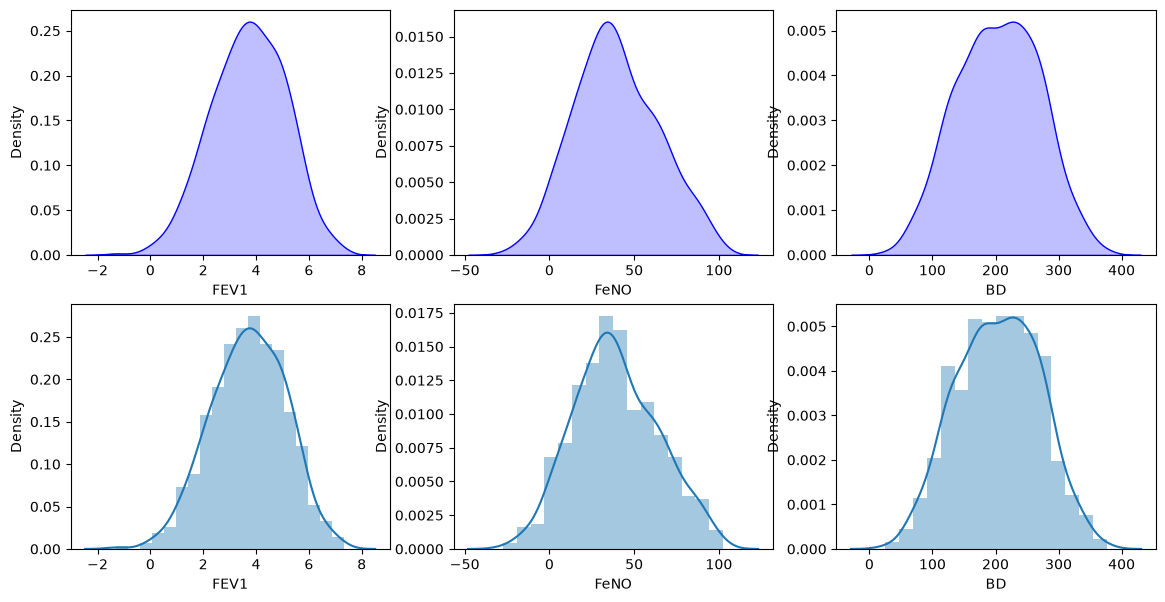

In [21]:
fig, axs = plt.subplots(2, 3, figsize=(14, 7))
sns.kdeplot(df['FEV1'], shade=True, color="b", ax=axs[0, 0])
sns.kdeplot(df['FeNO'], shade=True, color="b", ax=axs[0, 1])
sns.kdeplot(df['BD'], shade=True, color="b", ax=axs[0, 2])
sns.distplot( a=df["FEV1"], hist=True, kde=True, rug=False, ax=axs[1, 0])
sns.distplot( a=df["FeNO"], hist=True, kde=True, rug=False, ax=axs[1, 1])
sns.distplot( a=df["BD"], hist=True, kde=True, rug=False, ax=axs[1, 2])
plt.show()

## 4. Build QQ-Plots to Double-Check Gaussian Distribution
By visual inspection, our data seems to be close to the Gaussian distribution. We can double-check building qq-plots:

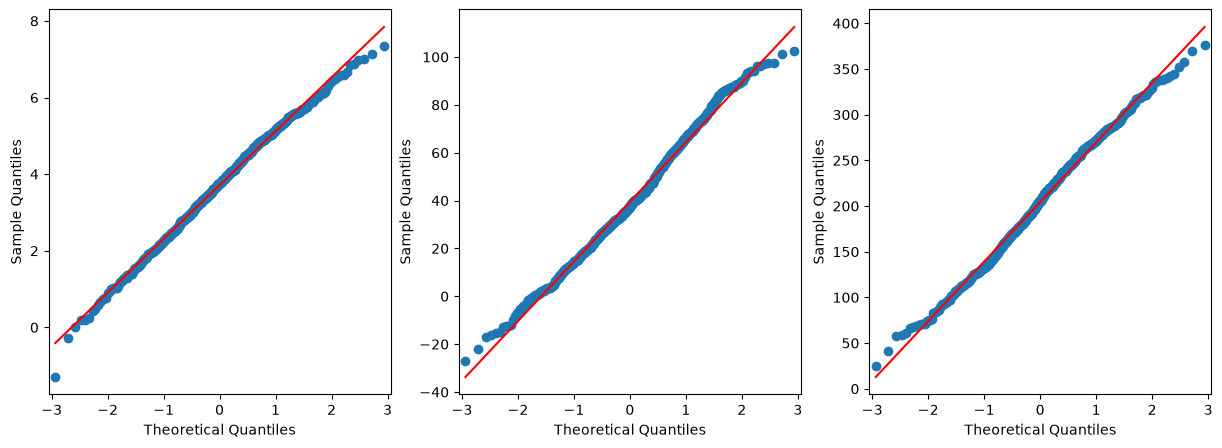

In [22]:
#! pip install statsmodels
from statsmodels.graphics.gofplots import qqplot
from matplotlib import pyplot
#q-q plot:
fig, axs = pyplot.subplots(1, 3, figsize=(15, 5))
qqplot(df['FEV1'], line='s', ax=axs[0])
qqplot(df['FeNO'], line='s', ax=axs[1])
qqplot(df['BD'], line='s', ax=axs[2])
pyplot.show()

. Build a Pair-Plot to Explore the Data Set 
We don’t have a perfect normal distribution for our variables, but we are close enough and able to use them. To explore our data set and the correlations between variables, we will build a pair-plot:



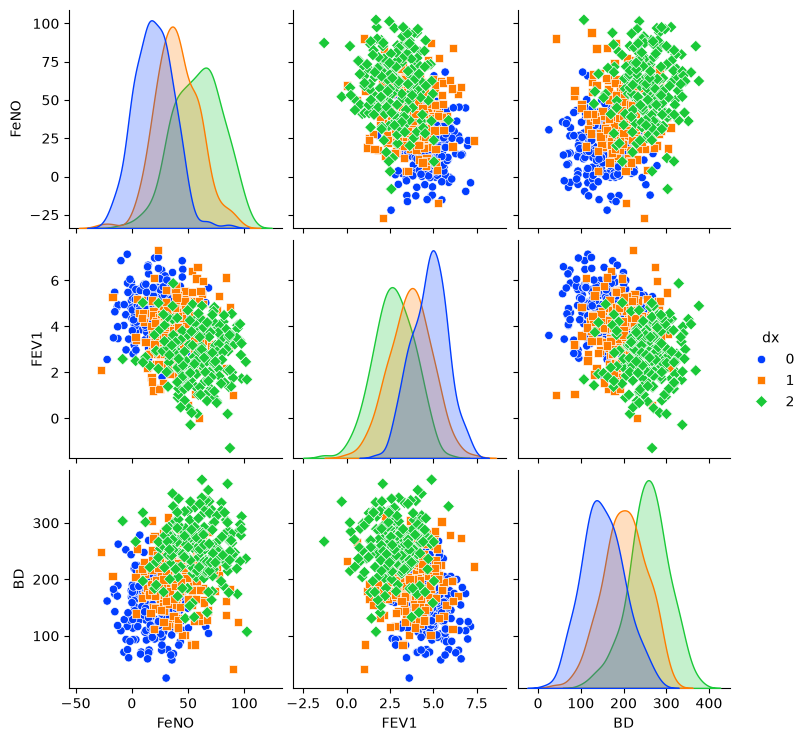

In [27]:
#Exploring detaset:
sns.pairplot(df, hue='dx',kind="scatter",palette="bright",diag_kind="kde",markers=["o", "s", "D"])

6. Create a Box-Plot to Check Parameters
Next we’ll build a boxplot graph to check the distributions for the three groups and see which parameters best distinguish the categories:

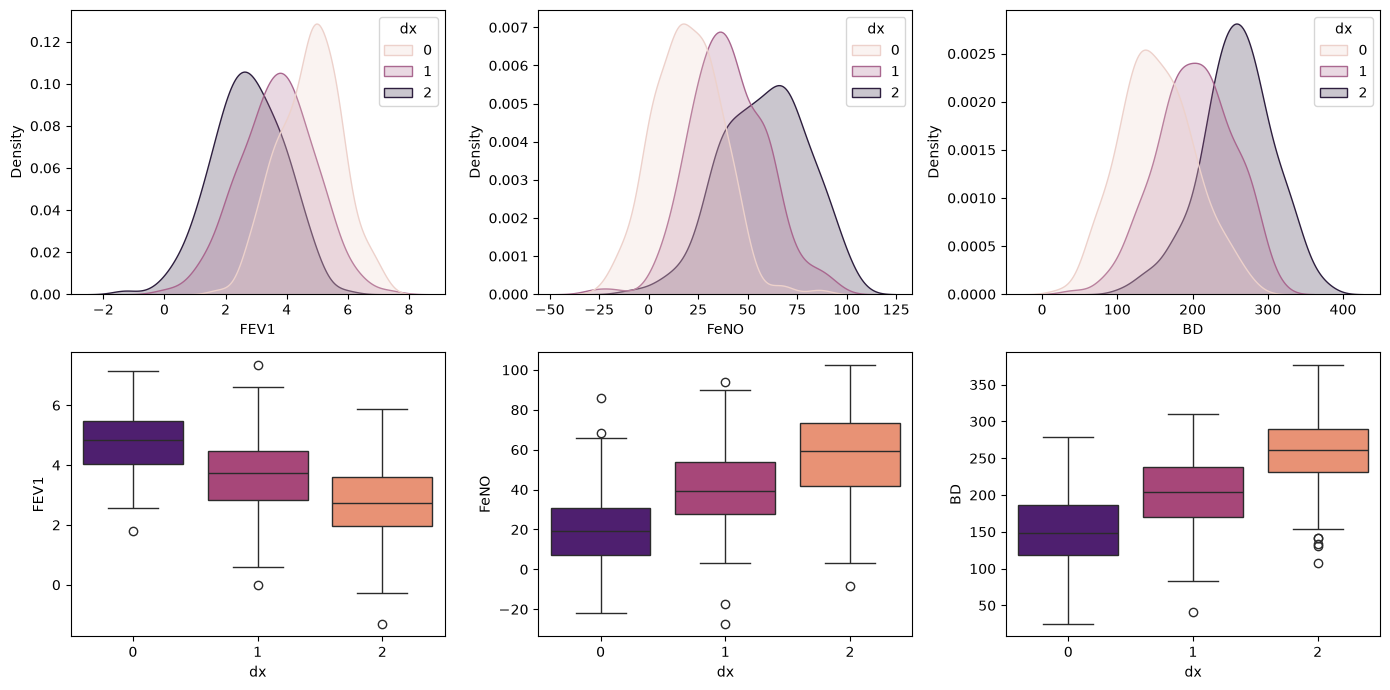

In [28]:
# Plotting both distributions on the same figure
fig, axs = plt.subplots(2, 3, figsize=(14, 7))

# Top row: KDE plots (Note: fill=True replaces the deprecated shade=True)
sns.kdeplot(data=df, x='FEV1', hue='dx', fill=True, ax=axs[0, 0])
sns.kdeplot(data=df, x='FeNO', hue='dx', fill=True, ax=axs[0, 1])
sns.kdeplot(data=df, x='BD',   hue='dx', fill=True, ax=axs[0, 2])

# Bottom row: Box plots
sns.boxplot(data=df, x='dx', y='FEV1', palette='magma', ax=axs[1, 0])
sns.boxplot(data=df, x='dx', y='FeNO', palette='magma', ax=axs[1, 1])
sns.boxplot(data=df, x='dx', y='BD',   palette='magma', ax=axs[1, 2])

plt.tight_layout()  # Fixes overlapping labels between rows
plt.show()


In [29]:
#Creating a Function:
def normal_dist(x , mean , sd):
      prob_density = (1/sd*np.sqrt(2*np.pi)) * np.exp(-0.5*((x-mean)/sd)**2)
      return prob_density

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Import the 4 classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# --- STEP 1: CREATE MOCK DATA ---
# (Simulating your df with FEV1, FeNO, BD, and dx)
np.random.seed(42)
n_samples = 200
data = {
    'FEV1': np.random.normal(80, 10, n_samples),
    'FeNO': np.random.normal(35, 15, n_samples),
    'BD': np.random.normal(12, 5, n_samples),
    'dx': np.random.choice([0, 1], size=n_samples) # 0 = Healthy, 1 = Asthma
}
df = pd.DataFrame(data)

# Split features (X) and target label (y)
X = df[['FEV1', 'FeNO', 'BD']]
y = df['dx']

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (Required for Logistic Regression and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- STEP 2: TRAIN AND COMPARE MODELS ---
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Support Vector Machine": SVC(kernel='linear')
}

print("--- MODEL ACCURACY RESULTS ---")
for name, model in models.items():
    # Use scaled data for distance/probability models, raw data works fine for Trees
    X_tr = X_train_scaled if name != "Decision Tree" else X_train
    X_te = X_test_scaled if name != "Decision Tree" else X_test
    
    # Train the model
    model.fit(X_tr, y_train)
    
    # Predict and calculate accuracy
    predictions = model.predict(X_te)
    acc = accuracy_score(y_test, predictions)
    
    print(f"{name}: {acc * 100:.1f}% accuracy")


# --- STEP 3: UNDERSTANDING THE MODELS WITH SIMPLE QUESTIONS ---

"""
QUESTION 1: Which model should you use if your medical board demands 
to see a strict flowchart of how a patient was diagnosed?
--> ANSWER: Decision Tree. It generates clear if-then split rules.

QUESTION 2: Which model assumes that a patient's 'FeNO' level has 
absolutely zero mathematical relationship to their 'FEV1' score?
--> ANSWER: Naive Bayes. It assumes all features are completely independent.

QUESTION 3: Which model looks for the widest possible physical safety 
corridor to separate the Healthy cluster from the Asthma cluster?
--> ANSWER: Support Vector Machine (SVM). It maximizes the decision margin.

QUESTION 4: Which model directly calculates the exact percentage risk 
probability (e.g., 'This patient has a 78% chance of illness')?
--> ANSWER: Logistic Regression. It outputs a probability curve between 0 and 1.
"""


--- MODEL ACCURACY RESULTS ---
Logistic Regression: 67.5% accuracy
Naive Bayes: 60.0% accuracy
Decision Tree: 55.0% accuracy
Support Vector Machine: 62.5% accuracy


"\nQUESTION 1: Which model should you use if your medical board demands \nto see a strict flowchart of how a patient was diagnosed?\n--> ANSWER: Decision Tree. It generates clear if-then split rules.\n\nQUESTION 2: Which model assumes that a patient's 'FeNO' level has \nabsolutely zero mathematical relationship to their 'FEV1' score?\n--> ANSWER: Naive Bayes. It assumes all features are completely independent.\n\nQUESTION 3: Which model looks for the widest possible physical safety \ncorridor to separate the Healthy cluster from the Asthma cluster?\n--> ANSWER: Support Vector Machine (SVM). It maximizes the decision margin.\n\nQUESTION 4: Which model directly calculates the exact percentage risk \nprobability (e.g., 'This patient has a 78% chance of illness')?\n--> ANSWER: Logistic Regression. It outputs a probability curve between 0 and 1.\n"

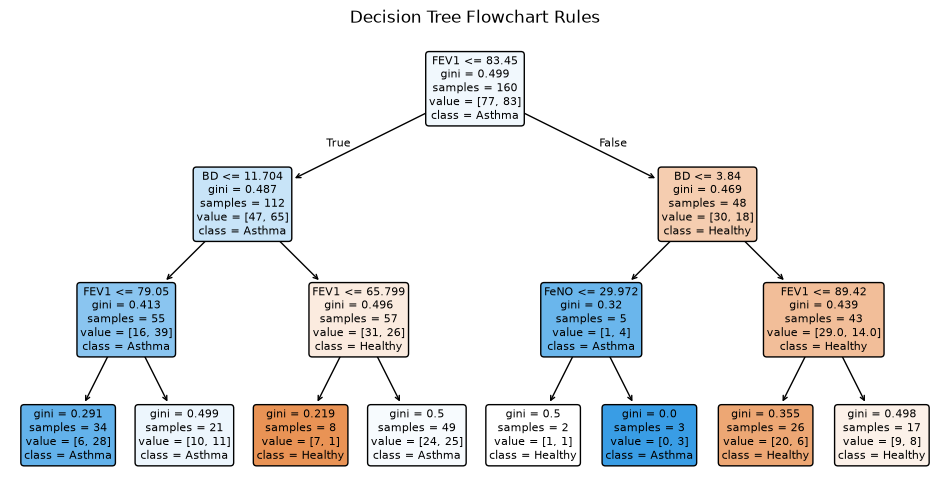

In [35]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Set up the figure size
plt.figure(figsize=(12, 6))

# Plot the trained decision tree
plot_tree(
    models["Decision Tree"], 
    feature_names=['FEV1', 'FeNO', 'BD'], 
    class_names=['Healthy', 'Asthma'], 
    filled=True, 
    rounded=True
)

plt.title("Decision Tree Flowchart Rules")
plt.show()


## SVN simple example

In [37]:
from sklearn import svm
#Features
X=[[-3,-1],[0,2],[3,1],[3,3],[1,1],[.5,1.5],[-3,-3],[0,-2],[3,-1],[3,-3],[1,-1],[.5,-1.5]]
#labels
y=[0,0,0,0,0,0,1,1,1,1,1,1]
#Create SVM classifier
clf = svm.SVC(kernel='linear', C=1.0)
clf.fit(X, y)
clf.predict([[0, 0], [2, 2], [-2, -2]])

array([0, 0, 1])